In [1]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway/clean_stuff

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway/clean_stuff


In [2]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import numpy as np
import torch # long
from lightning.pytorch import loggers, seed_everything
import xarray as xr
from lightning.pytorch import  seed_everything
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)


Running imports...


Seed set to 42


42

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_backtoclassif", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


In [9]:
from src.data import MyDataLoader

In [10]:
loader = MyDataLoader(wandb_logger)


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/xarray/core/indexing.py:1679: PerformanceWarning: Slicing with an out-of-order index is generating 1384 times more chunks
  return self.array[key]


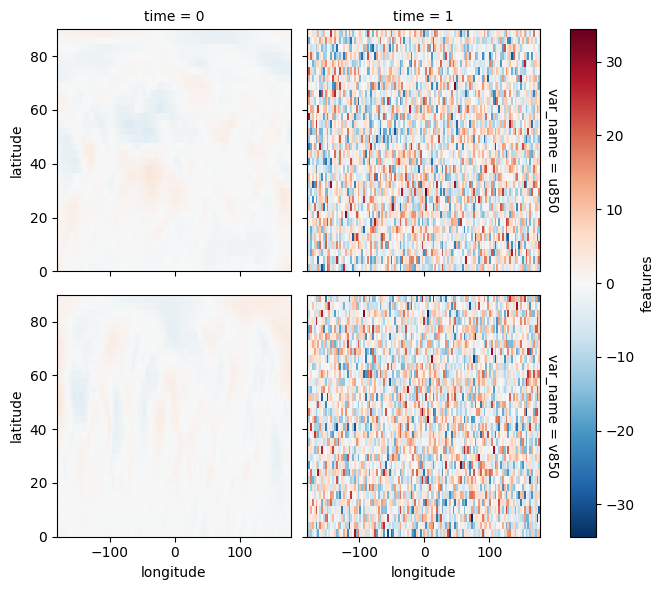

In [ ]:
loader.ds_train.sel(time='1969-01-10').features.assign_coords(time=[0,1,2,3]).plot(col='time', row='var_name')

In [143]:
wandb.finish()

In [95]:
ds = loader.get_ds_train()

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/xarray/core/indexing.py:1679: PerformanceWarning: Slicing with an out-of-order index is generating 1377 times more chunks
  return self.array[key]


In [ ]:
import dask


In [136]:
ds_out

<xarray.Dataset> Size: 10GB
Dimensions:    (time: 151844, var_name: 2, latitude: 32, longitude: 128,
                timestep: 4)
Coordinates:
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name   (var_name) object 16B 'u850' 'v850'
  * time       (time) datetime64[ns] 1MB 1967-02-01 1984-02-25 ... 1975-01-10
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    mask_id    int64 8B 14
    quantile   float64 8B 0.9
Dimensions without coordinates: timestep
Data variables:
    features   (time, var_name, latitude, longitude) float64 10GB dask.array<chunksize=(1, 1, 8, 32), meta=np.ndarray>
    targets    (time, timestep) int64 5MB 0 1 2 1 1 0 1 1 1 ... 1 1 1 2 1 1 1 2
    rain       (time, timestep) float32 2MB 0.7499 9.335 25.07 ... 13.92 25.83

In [142]:
shuffled_time = np.arange(ds_out.time.size)
np.random.shuffle(shuffled_time)
ds_out.isel(time=shuffled_time)

<xarray.Dataset> Size: 10GB
Dimensions:    (time: 151844, var_name: 2, latitude: 32, longitude: 128,
                timestep: 4)
Coordinates:
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name   (var_name) object 16B 'u850' 'v850'
  * time       (time) datetime64[ns] 1MB 1996-08-02 1994-01-08 ... 1986-04-07
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    mask_id    int64 8B 14
    quantile   float64 8B 0.9
Dimensions without coordinates: timestep
Data variables:
    features   (time, var_name, latitude, longitude) float64 10GB dask.array<chunksize=(1, 1, 8, 32), meta=np.ndarray>
    targets    (time, timestep) int64 5MB 1 1 1 0 1 0 0 0 1 ... 1 1 1 1 0 0 0 0
    rain       (time, timestep) float32 2MB 17.87 5.234 4.536 ... 0.2446 0.1134